# Project 1 - Graph Search

refer to the project write up [here](https://rutgers.app.box.com/s/nmmj14j4g70nbltswcq8ooeqde3okp5x)

### The Ship

 - This is represented with an nxn grid of closed cells
 - Choose a random interior square to 'open'
 - neighbors of a cell are 1 unit away in cardinal directions
 - Iteratively: open up the ship, following protocol described in writeup
 - Identify dead ends -> for half of them pick a closed neighbor and open it

### Our Implementation:
 - We're using a numpy n x n matrix to represent the grid, and we show it using matplotlib
 - We use numerical encodings to represent different states of a cell.

 
 ### Codes:
  - 0 -> open
  - 1 -> closed
  - 2 -> fire
  - 3 -> bot
  - 4 -> button


In [364]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import time
from matplotlib.colors import ListedColormap, BoundaryNorm

In [365]:
matr = np.random.randn(3,3)

for ind, cell in np.ndenumerate(matr):
    print(f'Index: {ind}, cell: {cell}')

Index: (0, 0), cell: -0.05557135172362688
Index: (0, 1), cell: 0.28344346456539415
Index: (0, 2), cell: 0.6575843265951113
Index: (1, 0), cell: -0.7304681545185866
Index: (1, 1), cell: 0.7755519682700834
Index: (1, 2), cell: -1.5693630868775583
Index: (2, 0), cell: -0.5227319150242937
Index: (2, 1), cell: 1.1379578807865003
Index: (2, 2), cell: -1.1739961026784147


In [366]:
# Let's package this all into a class
class ship:    
    
    def __init__(self,data, open = set(), fire = set(), button = (), bot = (), closed = set()):
        self.data = data # this should be numpy matrix
        self.open = open # set of tuples, each tuple has indices of open cell
        self.fire = fire # set of tuples, each tuple has indices of fire cell
        self.button = button #tuple
        self.bot = bot # tuple
        self.closed = closed # list of tuples

    @classmethod
    def CreateShip(cls,n):
        ship = cls(np.ones((n,n), dtype = float))
        #Pick random cell in interior to open
        x_rand, y_rand = random.randint(1, ship.data.shape[0]-2) , random.randint(1, ship.data.shape[1]-2)
        ship.data[x_rand][y_rand] = 0
        ship.open = {(x_rand, y_rand)} # We use {} to make a set, now we don't have to worry about any duplicates
        return ship

    def ShowShip(self):
        colors = ['white', 'black', 'red', 'blue', 'green']
        custom_map = ListedColormap(colors)
        bounds = [-.1, .5, 1.5, 2.5, 3.5, 4.5]
        norm = BoundaryNorm(bounds, custom_map.N)
        plt.imshow(self.data, cmap = custom_map, norm=norm)
        

        #Ensure shows plot with increments of 1
        plt.xticks(np.arange(-0.5, self.data.shape[1], 1), labels=[])
        plt.yticks(np.arange(-0.5, self.data.shape[0], 1), labels=[])

        #Show gridlines
        plt.grid(True)

        #Show colorbar
        plt.colorbar()
        plt.show()

    #Helper method that takes in indices and returns list of tuples that is 4 cardinal neighbors
    @staticmethod
    def getNeighbors(ind):
        up = (ind[0]-1, ind[1])
        down = (ind[0]+1, ind[1])
        left = (ind[0], ind[1]-1)
        right = (ind[0], ind[1]+1)
        return [up, down, left, right]
        

    #Helper method for robot motion, returns neighbors that are inbounds, open, and not on fire
    @staticmethod
    def getAdj(self, ind):
        try:
            up = (ind[0]-1, ind[1])
            if up in self.closed or up in self.fire or up[0] >= len(self.data) or up[1] >= len(self.data) or up[0] < 0 or up[1] < 0:  
                up = None
        except IndexError:
            up = None
        try:
            down = (ind[0]+1, ind[1])
            if down in self.closed or down in self.fire or down[0] >= len(self.data) or down[1] >= len(self.data) or down[0] < 0 or down[1] < 0:  
                down = None
        except IndexError:
            down = None
        try:
            left = (ind[0], ind[1]-1)
            if left in self.closed or left in self.fire or left[0] >= len(self.data) or left[1] >= len(self.data) or left[0] < 0 or left[1] < 0:  
                left = None
        except IndexError:
            left = None
        try:
            right = (ind[0], ind[1]+1)
            if right in self.closed or right in self.fire or right[0] >= len(self.data) or right[1] >= len(self.data) or right[0] < 0 or right[1] < 0:  
                right = None
        except IndexError:
            right = None
        coors = [up, down, left, right]
        for i in coors:
            if i == None:
                coors.remove(i)
        return coors

    # Helper to see if indices are within upper and lower bounds
    @staticmethod
    def checkBounds(upper, lower, ind):
        for i in ind:
            if i > upper or i < lower:
                return False
        return True
    
    #Helper method that takes a list of directions and ensures they're w/in bounds
    def getInbounds(self, dir):
        k = 0
        while k in range(len(dir)):
            if not ship.checkBounds(self.data.shape[0]-1, 0, dir[k]):
                del dir[k]
            else:
                k+=1
        return dir
        

    # Helper method, takes in an open cell and returns list of closed neighbors
    def checkNeighborsOpen(self, openInd):
        neighbors = ship.getNeighbors(openInd)
        valid,k = self.getInbounds(neighbors),0
        while k in range(len(valid)):
            r, c = valid[k] #unpack tuple
            if self.data[r][c] != 1:
                del valid[k]
            else:
                k+=1
        return valid
        
    #Takes in index which is a tuple that represents a cell. Checks to see if it has exactly one open neighbor
    def checkNeighborsClosed(self, Ind):
        neighbors = ship.getNeighbors(Ind)
        valid = self.getInbounds(neighbors)
        numOpen = 0
        for direction in valid:
            i,j = direction
            if self.data[i][j] == 0:
                numOpen+=1
        if numOpen == 1:return True
        return False
    
    #returns the neighboring cells of coordinate that are fire cells
    def checkFireNeighbors(self, coordinate):
        adjCells = self.getNeighbors(coordinate)
        adjCells = self.getInbounds(adjCells)
        fireCells = []
        for cell in adjCells:
            if self.data[cell[0]][cell[1]]==2: fireCells.append((cell[0],cell[1]))
        return fireCells

    #returns a list of open cells with exactly one open neighbor
    def getDeadEnds(self):
        dead_ends = []
        for openInd in self.open:
            if self.checkNeighborsClosed(openInd):
                dead_ends.append(openInd)
        return dead_ends

    def openDeadEnds(self):
        dead_ends = self.getDeadEnds()
        for i in range(len(dead_ends)//2): # Want to open ~half the dead ends
            valid_neighbors = self.getInbounds(ship.getNeighbors(dead_ends[i]))
            closed_neighbors = []
            for neighbor in valid_neighbors:
                i,j = neighbor
                if self.data[i][j] == 1:
                    closed_neighbors.append(neighbor)

            #Now we have closed neighbors of dead end, choose one at random and open
            ri = None
            if len(closed_neighbors)-1 > 0:
                ri = random.randint(0, len(closed_neighbors)-1)
                rx, ry = closed_neighbors[ri]
                self.data[rx][ry] = 0

    # In order to more efficiently open the ship we only check the blocked cells that are next to open cells
    # Then we can see which of those blocked cells has exactly 1 open neighbor.
    # While this set is not empty, we choose a random elt in the set to open
    def OpenShip(self):
        while True:
            possibly_valid_blocked, valid_blocked = [],[]
            for open in self.open:
                possibly_valid_blocked += self.checkNeighborsOpen(open)
            for possibly_valid in possibly_valid_blocked:
                if self.checkNeighborsClosed(possibly_valid): valid_blocked.append(possibly_valid)
            if len(valid_blocked) != 0:
                #choose random valid blocked and open it
                ri = random.randint(0, len(valid_blocked)-1)
                i, j = valid_blocked[ri]
                self.data[i][j] = 0 # Open randomly chosen cell
                self.open.add((i,j)) # Add this to set of open cells
            else:
                break
    

    def chooseInitSpawns(self):
        #Don't need to choose random indices since self.open is an unordered set so popping off the top is effectively random
        obj_ind = [self.open.pop() for i in range(3)]
        for i in range(len(obj_ind)):
            x,y = obj_ind[i]
            self.data[x][y] = i+2
        self.button = obj_ind[2]
        self.bot = obj_ind[1]
        self.fire.add(obj_ind[0])
    
    def spreadFire(self, probability):
        gameOver = False
        fireNeighbors = []
        for fireCoor in self.fire:
            fireNeighbors.append(self.getAdj(self,fireCoor))
        for coordinates in fireNeighbors:
            coordinates = [coor for coor in coordinates if coor is not None] # eliminating 'None' elements from the coordinates list
            coordinates = self.getInbounds(coordinates)
            for coordinate in coordinates:
                k = len(self.checkFireNeighbors(coordinate))
                prob = (1-((1-probability)**k))*100
                randNum = (random.random())*100
                if randNum < prob:
                    self.fire.add(coordinate)
                    self.data[coordinate[0]][coordinate[1]]=2
                    if (self.bot == coordinate) or (self.button == coordinate):
                        gameOver = True
        return gameOver
    
#     def bot1(self, adjMatrix):
#         # we will have an adjacency matrix set up that contains all the open cells
#         # before the fire starts spreading. we should calculate the shortest path to the button, avoiding the initial fire cell
#         # then run the simulation
        
#     def bot2(self, openCelladjMatrix):
#         # same as bot1 but for each timestep we recalculate the time step with BFS
        
#     def bot3(self, openCelladjMatrix, fireHashmap):
#         #Similar to bot3 except we are expanding the number of items in the fireHashmap to include adjacent cells to fire cells
#         #if a shortest path with the expanded fireHashmap cannot be found, then use the formula from bot2 to find a shortest path
        
#     def bot4(self, openCellADjMatrix, fireHashmap):
#         #use a heuristic function to add weights to the neighbors of the bot to make a smarter decision
#         # heuristic function will consider many parameters such as where the fire is, linear distance to button,
#             # **we could potentially add dead ends as part of our heuristic**

    def populateClosedCells(self):
        for i in range(len(self.data)):
            for j in range(len(self.data[0])):
                if self.data[i][j]==1:
                    self.closed.add((i,j))
    
    #we might be able to get rid of this function
    def checkBotInFire(self):
        for coor in self.fire:
            if coor == self.bot:
                return True
        return False
    
    def bot1(self):
        startPos = self.bot
        q = deque([(startPos, [startPos])])
        vis = set()
        vis.add(startPos)
        while len(q) > 0:
            curNode , path = q.popleft()
            if curNode == self.button:
                return path + [curNode]
            neighbors = self.getAdj(self, curNode)
            neighbors = [n for n in neighbors if n is not None]
            for child in neighbors:
                if child not in vis and child not in self.fire:
                    q.append((child, path + [child]))
                    vis.add(child)
        return None
        
    def moveBot(self, newPos):
        oldPos = self.bot
        self.bot = newPos
        self.data[newPos[0]][newPos[1]] = 5
        self.data[oldPos[0]][oldPos[1]] = 0

    def cleanPath(self, path):
        path.remove(self.bot)
        path.remove(self.button)
        if path == None: raise ValueError

    def bot1Runner(self):
        time = 0
        gameOver = False
        path = self.bot1()
        path.remove(self.bot)
        path.remove(self.button)
        if path == None: return False
        while(True and not gameOver): #put in 'time<3' so loop doesn't go on forever
            self.checkBotInFire()
            if time > len(path):
                print("false")
                return
            move = path[time]
            self.moveBot(move)
            if self.bot == self.button:
                print("Success")
                return
            gameOver = self.spreadFire(0.5)
            time += 1
            # self.ShowShip()
        if gameOver:
            print("Game over after "+str(time)+" turns")

    def bot2Runner(self):
        time = 0
        gameOver = False
        path = self.bot1()
        self.cleanPath(path)
        while(True and not gameOver):
            self.checkBotInFire()
            print("Inital Path", path) 
            move = path[0]
            print("Inital Move", move)
            self.moveBot(move)
            if self.bot == self.button:
                print("Success")
                return
            gameOver = self.spreadFire(0.65)
            time += 1
            self.ShowShip()
            path = self.bot1()
            print("Potential path", path)
            if path == None:
                print("failure")
                return
            self.cleanPath(path)
            print("New Calculated Path", path)
        if gameOver:
            print("Game over after "+str(time)+" turns")
    
            



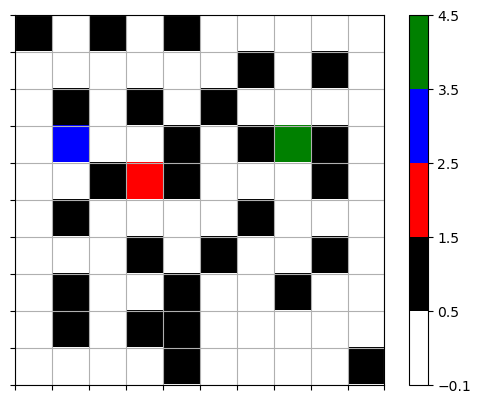

Inital Path [(3, 2), (2, 2), (1, 2), (1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Move (3, 2)


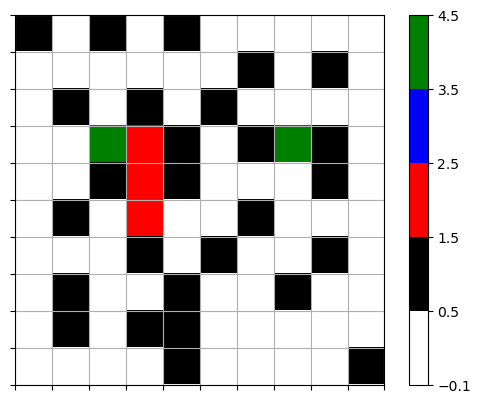

Potential path [(3, 2), (2, 2), (1, 2), (1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (3, 7)]
New Calculated Path [(2, 2), (1, 2), (1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Path [(2, 2), (1, 2), (1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Move (2, 2)


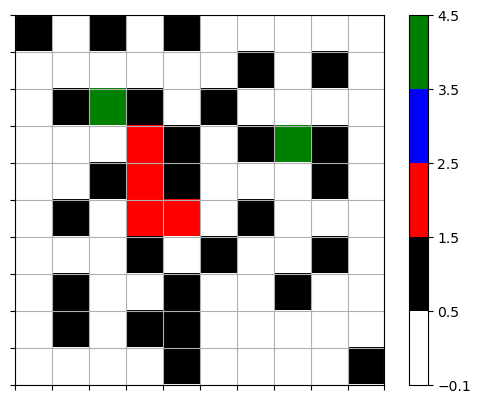

Potential path [(2, 2), (1, 2), (1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (3, 7)]
New Calculated Path [(1, 2), (1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Path [(1, 2), (1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Move (1, 2)


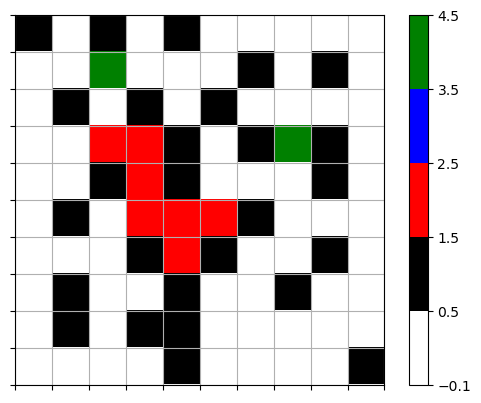

Potential path [(1, 2), (1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (3, 7)]
New Calculated Path [(1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Path [(1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Move (1, 3)


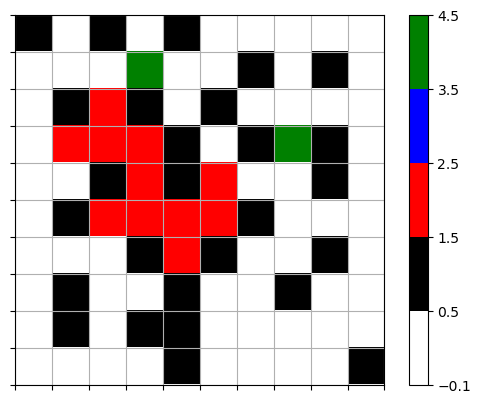

Potential path [(1, 3), (1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (3, 7)]
New Calculated Path [(1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Path [(1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Move (1, 4)


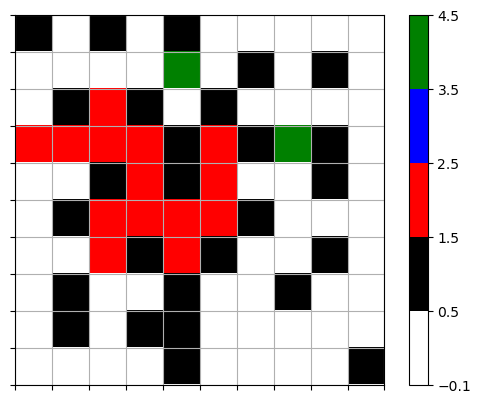

Potential path [(1, 4), (1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (3, 7)]
New Calculated Path [(1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Path [(1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Move (1, 5)


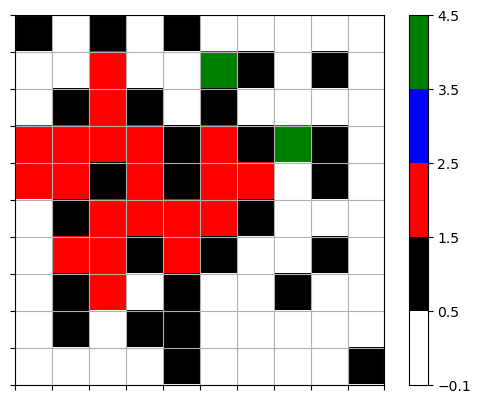

Potential path [(1, 5), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (3, 7)]
New Calculated Path [(0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Path [(0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Move (0, 5)


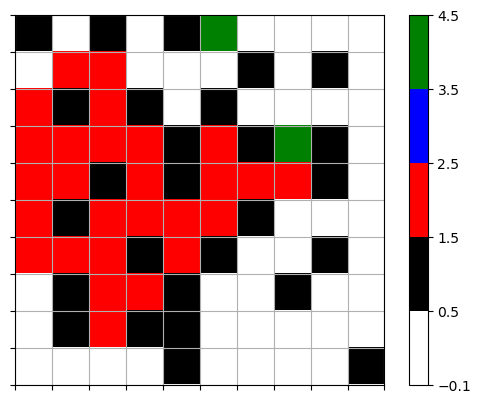

Potential path [(0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (3, 7)]
New Calculated Path [(0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Path [(0, 6), (0, 7), (1, 7), (2, 7), (3, 7)]
Inital Move (0, 6)


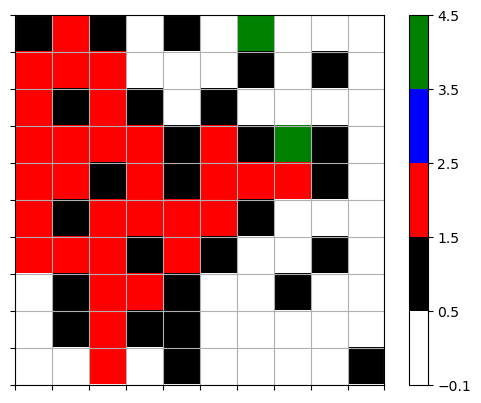

Potential path [(0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (3, 7)]
New Calculated Path [(0, 7), (1, 7), (2, 7), (3, 7)]
Inital Path [(0, 7), (1, 7), (2, 7), (3, 7)]
Inital Move (0, 7)


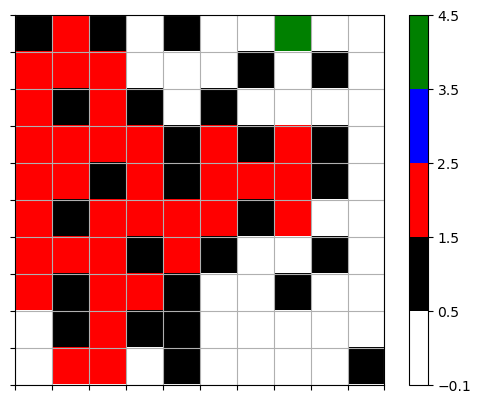

Potential path None
failure


In [367]:
space_ship = ship.CreateShip(10)
space_ship.OpenShip()
space_ship.openDeadEnds()
space_ship.populateClosedCells()
space_ship.chooseInitSpawns()
space_ship.ShowShip()
space_ship.bot2Runner()